# Example 3 – INP: monodisperse vs lognormal size distributions

This example explores how the assumed size distribution of ice-nucleating particles
(INPs) affects predicted freezing behavior.

We compare two populations that have the **same total ice-nucleating surface area**
but different size distributions:

- A **monodisperse** population (all particles same size).
- A **lognormal** population (broad size distribution).

Both are passed through the same ice nucleation parameterization, and we compare the
resulting frozen fractions.

### What you’ll learn

- How to construct INP populations using `build_population` and
  `build_freezing_population`.
- How to sample an ice-nucleating surface area (INSA) distribution.
- How differences in size distribution alone can affect predicted freezing.

## Step 1 – Define an INSA distribution and build baseline population

We first construct a synthetic **ice-nucleating surface area (INSA)** distribution that roughly follows the example from Alpert & Knopf (2016). Here, INSA is expressed as surface area per particle.

From this INSA distribution, we will create two idealized populations:

- A **monodisperse** population where all particles have the same INSA.
- A **lognormal** population that preserves the *total* INSA but redistributes it across a range of particle sizes.

This lets us isolate the impact of size distribution on freezing, holding total INSA fixed.


In [1]:
from part2pop.population import build_population
import numpy as np
import warnings
from part2pop.viz.style import StyleManager, Theme
from part2pop.viz.builder import build_plotter
import matplotlib.pyplot as plt
%matplotlib inline  

#warnings.filterwarnings("ignore")

# sample a lognormal INSA distribution to match the example in 
# P. A. Alpert and D. A. Knopf: A unifying ice nucleation model
lognormal_cfg = {"type": "binned_lognormals",
                 "N": [1e9],
                 "GMD": [np.sqrt(1e-9/np.pi)],
                 "GSD": [np.sqrt(10.0)],
                 "N_bins": [30],
                 "aero_spec_names": [["OC"]],
                 "aero_spec_fracs": [[1.0]],
                 "species_modifications": {'OC': {'m_log10_Jhet': 0.0, 'b_log10_Jhet': 7.0}}            
}

monodisperse_cfg = {"type": "monodisperse",
                    "N": [1e9],
                    "D": [np.sqrt(1e-9/np.pi)], 
                    "aero_spec_names": [["OC"]],
                    "aero_spec_fracs": [[1.0]],
                    "species_modifications": {'OC': {'m_log10_Jhet': 0.0, 'b_log10_Jhet': 7.0}}            
}

# Build underlying particle populations
pop_configs = [lognormal_cfg, monodisperse_cfg]
lognorm_pop = build_population(lognormal_cfg)
mono_pop = build_population(monodisperse_cfg)


## Step 2 – Attach a freezing parameterization

Next we use `build_freezing_population` to wrap each size distribution with a freezing
parameterization.

The configuration (`var_cfg`) specifies:

- The **morphology** (e.g. `homogeneous` vs other modes).
- Any **temperature** or **supersaturation** grids to evaluate.
- Any additional parameters required by the chosen parameterization.

The result is a `FreezingPopulation` that can be queried for freezing metrics such as frozen
fraction as a function of temperature.


In [2]:
# plot the ice nucleating surface area distribution

from part2pop.freezing import build_freezing_population

var_cfg = {"morphology": "homogeneous",
            "T_grid": [-30],
            "T_units": "C"
}

# Build freezing config from variable cfg and population Jhets
frz_cfg = dict(var_cfg)

# Build population of FreezingParticles
monodisperse_frz_pop = build_freezing_population(mono_pop, frz_cfg)
lognormal_frz_pop = build_freezing_population(lognorm_pop, frz_cfg)

print("Properties of FreezingPopulation:", lognormal_frz_pop.__dict__.keys())


Properties of FreezingPopulation: dict_keys(['species', 'spec_masses', 'num_concs', 'ids', 'classes', 'species_modifications', 'm_log10_Jhet', 'b_log10_Jhet', 'INSA'])


## Step 3 – Plot ice nucleating surface area distribution

Here we evaluate the ice nucelating surface area distribution using the viz package.

Questions to ask:

- How is the ice nucleating surface area different for the lognormal and monodisperse populations?

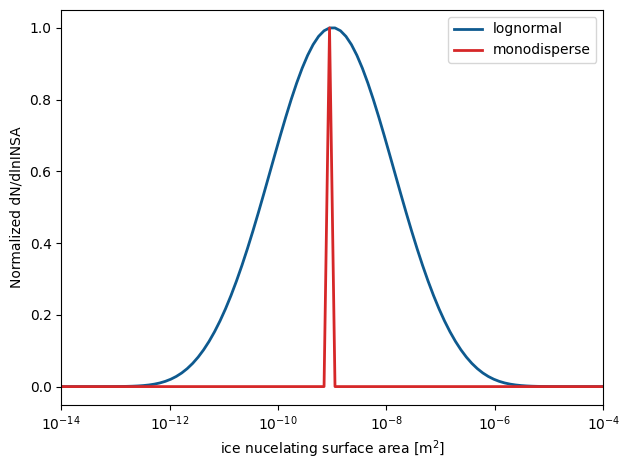

In [3]:
# plot the ice nucleating surface area distribution using viz package
mgr = StyleManager(Theme(), deterministic=True)
series = [
    {"key": "lognorm", "population": lognorm_pop, "label": r"lognormal"},
    {"key": "mono", "population": mono_pop, "label": r"monodisperse"},
]
line_styles = mgr.plan("line", [s["key"] for s in series])

fig, ax = plt.subplots()
for s in series:
    cfg = {"varname": "INSA_distribution",
            "var_cfg": {"insa_grid": np.logspace(-14,-4, 100), "normalize": True},  
            "style": line_styles[s["key"]],
    }
    plotter = build_plotter("state_line", cfg)
    plotter.plot(s["population"], ax, label=s["label"])
ax.legend(); fig.tight_layout()
plt.show()

## Step 4 – Evaluate unfrozen fraction vs time for an isothermal experiment

Here we evaluate the unfrozen fraction for each population over time at a given temperature. Because the unfrozen fraction is normalized by the total number concentration in each population, any differences in the curves are purely due to differences in the ice nucleating surface area.

Questions to ask:

- Does the monodisperse population freeze more or less efficiently than the lognormal?
- Are differences largest at colder or warmer temperatures?


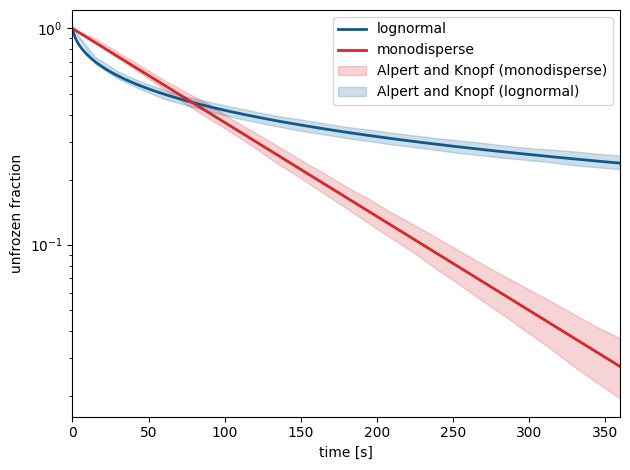

In [4]:
# Plot the expected frozen fraction over time for an isothermal experiment (dT/dt = 0.0)
# These lines will be plotted for each value in T_grid of the FreezingPopulation
mgr = StyleManager(Theme(), deterministic=True)
series = [
    {"key": "lognorm", "population": lognorm_pop, "label": r"lognormal"},
    {"key": "mono", "population": mono_pop, "label": r"monodisperse"},
]
line_styles = mgr.plan("line", [s["key"] for s in series])

fig, ax = plt.subplots()
for s in series:
    cfg = {"varname": "unfrozen_frac",
            "var_cfg": {'t_min': 0.0, "t_max": 360.0, "T": -30, "T_units": "C", "RH": 0.85},  
            "style": line_styles[s["key"]],
    }
    plotter = build_plotter("state_line", cfg)
    plotter.plot(s["population"], ax, label=s["label"])

# Data taken from P. A. Alpert and D. A. Knopf: A unifying ice nucleation model
import pandas as pd
AK_data = pd.read_csv("example_data/Alpert_Knopf_2016/Alpert_Knopf_2016_Fig1_data.csv")
ax.fill_between(AK_data['time'], AK_data['monodisperse_lower'], AK_data['monodisperse_upper'], color='#d62728', alpha=0.2, label='Alpert and Knopf (monodisperse)')
ax.fill_between(AK_data['time'], AK_data['lognormal_lower'], AK_data['lognormal_upper'], color='#0e5a8f', alpha=0.2, label='Alpert and Knopf (lognormal)')
ax.set_yscale('log')
ax.legend(); fig.tight_layout()
plt.show()



## Step 5 – Evaluate the population-average heterogeneous ice nucleation rate as a function of temperature.

Here we will plot the heterogeneous ice nucleation rate as a function of temperature for the monodisperse population defined previously. We will change the particle properties by altering `species_modifications` and compare.

Questions to ask:

- How does changing `m_log10Jhet` change the shape of the plot?
- How does changing `b_log10Jhet` change the shape of the plot?

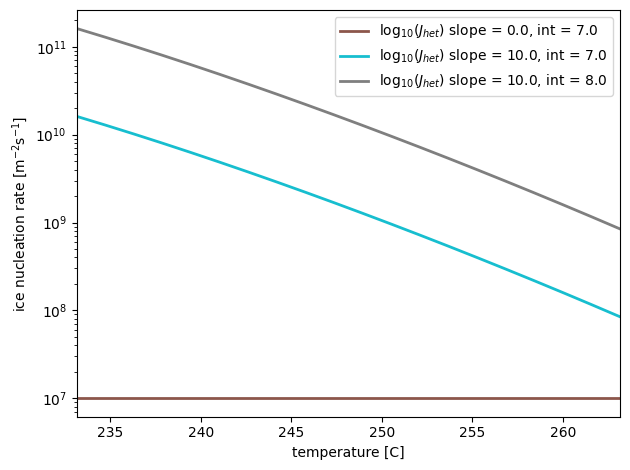

In [5]:
# copy the monodisperse population from previous steps
mono_pop_copy = build_population(monodisperse_cfg)

# plot the heterogeneous ice nucleation rate vs. temperature using viz package
mgr = StyleManager(Theme(), deterministic=True)

# alter the species properties
species_mods = [{"OC": {"m_log10_Jhet": 0.0, "b_log10_Jhet": 7.0}},
                {"OC": {"m_log10_Jhet": 10.0, "b_log10_Jhet": 7.0}},
                {"OC": {"m_log10_Jhet": 10.0, "b_log10_Jhet": 8.0}}]

series = [
    {"key": "orig", "population": mono_pop_copy, "label": r"log$_{10}(J_{het})$ slope = 0.0, int = 7.0"},
    {"key": "new_m", "population": mono_pop_copy, "label": r"log$_{10}(J_{het})$ slope = 10.0, int = 7.0"},
    {"key": "new_m_and_b", "population": mono_pop_copy, "label": r"log$_{10}(J_{het})$ slope = 10.0, int = 8.0"},
]
line_styles = mgr.plan("line", [s["key"] for s in series])

fig, ax = plt.subplots()
for s, specmod in zip(series, species_mods):
    cfg = {"varname": "avg_Jhet",
            "var_cfg": {"T_grid": np.linspace(-40, -10, 20), "T_units": "C", "species_modifications": specmod},
            "style": line_styles[s["key"]],
    }
    plotter = build_plotter("state_line", cfg)
    plotter.plot(s["population"], ax, label=s["label"])
ax.legend(); fig.tight_layout()
plt.show()


## Step 6 – Plot the probability of each particle freezing over a 1 s time step as a function of dry diameter.

Here we will use `viz` to plot the probability of heterogeneous freezing over 1 s a function of size for the organic particles defined in the last step. We will change the particle properties by altering `species_modifications` and compare.

Questions to ask:

- How does changing `m_log10Jhet` change the shape of the plot?
- Which particle sizes are most likely to freeze?
- How does changing the temperature change the shape of the plot?

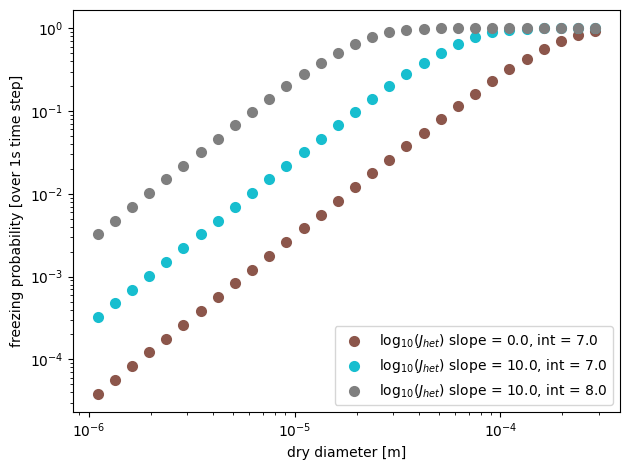

In [ ]:
# copy the lognormal population from previous steps
lognorm_pop_copy = build_population(lognormal_cfg)

# plot the heterogeneous ice nucleation rate vs. temperature using viz package
mgr = StyleManager(Theme(), deterministic=True)

# alter the species properties
species_mods = [{"OC": {"m_log10_Jhet": 0.0, "b_log10_Jhet": 7.0}},
                {"OC": {"m_log10_Jhet": 10.0, "b_log10_Jhet": 7.0}},
                {"OC": {"m_log10_Jhet": 10.0, "b_log10_Jhet": 8.0}}]

series = [
    {"key": "orig", "population": lognorm_pop_copy, "label": r"log$_{10}(J_{het})$ slope = 0.0, int = 7.0"},
    {"key": "new_m", "population": lognorm_pop_copy, "label": r"log$_{10}(J_{het})$ slope = 10.0, int = 7.0"},
    {"key": "new_m_and_b", "population": lognorm_pop_copy, "label": r"log$_{10}(J_{het})$ slope = 10.0, int = 8.0"},
]
line_styles = mgr.plan("line", [s["key"] for s in series])

# plot
fig, ax = plt.subplots()
for s, specmod in zip(series, species_mods):
    cfg = {"xvar": "Ddry",
            "yvar": "P_frz",
            "var_cfg": {"T": -10, "T_units": "C", "RH": 0.85, "species_modifications": specmod},
            "style": line_styles[s["key"]],
    }
    plotter = build_plotter("state_scatter", cfg)
    plotter.plot(s["population"], ax, label=s["label"])
ax.legend(); fig.tight_layout()
plt.show()
